<a href="https://colab.research.google.com/github/KishoreKumar477/ml-supervised/blob/main/Studentpds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub
path = kagglehub.dataset_download("aljarah/xAPI-Edu-Data")
print("Path to dataset files:", path)

100%|██████████| 5.54k/5.54k [00:00<00:00, 8.82MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/aljarah/xAPI-Edu-Data/versions/6


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler,LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [4]:
import pandas as pd
import numpy as np
import os

# Find CSV file
for file in os.listdir(path):
    print("Files in dataset:", file)

# Load the dataset (usually filename is 'heart.csv' or similar)
df = pd.read_csv(os.path.join(path, "xAPI-Edu-Data.csv"))

print(df.head(1).T)

Files in dataset: xAPI-Edu-Data.csv
                                   0
gender                             M
NationalITy                       KW
PlaceofBirth                  KuwaIT
StageID                   lowerlevel
GradeID                         G-04
SectionID                          A
Topic                             IT
Semester                           F
Relation                      Father
raisedhands                       15
VisITedResources                  16
AnnouncementsView                  2
Discussion                        20
ParentAnsweringSurvey            Yes
ParentschoolSatisfaction        Good
StudentAbsenceDays           Under-7
Class                              M


In [5]:
df = df.drop(['SectionID','Topic'], axis=1)


In [6]:
X=df.drop("Class",axis=1)
y=df["Class"]

In [7]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)   # e.g. {'H':0,'L':1,'M':2} (mapping shown below)
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))



Label mapping: {'H': np.int64(0), 'L': np.int64(1), 'M': np.int64(2)}


In [8]:
cat_cols = X.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)


Categorical columns: ['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID', 'Semester', 'Relation', 'ParentAnsweringSurvey', 'ParentschoolSatisfaction', 'StudentAbsenceDays']


In [9]:
preprocess = ColumnTransformer(
    [
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ],
    remainder='passthrough'
)


In [10]:
X_encoded = preprocess.fit_transform(X)

In [11]:
print("X_encoded shape:", X_encoded.shape)
print("y_encoded shape:", y_encoded.shape)


X_encoded shape: (480, 57)
y_encoded shape: (480,)


In [12]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_encoded, y_encoded)

print("After SMOTE class distribution (numeric):")
print(pd.Series(y_res).value_counts().sort_index())


After SMOTE class distribution (numeric):
0    211
1    211
2    211
Name: count, dtype: int64


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

In [25]:
model = XGBClassifier(
    learning_rate=0.1,
    n_estimators=350,
    max_depth=6,
    subsample=0.85,
    colsample_bytree=0.85,
    eval_metric='mlogloss',
    random_state=42
)


In [26]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.85, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=350, n_jobs=None,
              num_parallel_tree=None, ...)

In [27]:
y_pred_num = model.predict(X_test)


In [28]:
y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred_num)


In [29]:
print("Improved Accuracy:", accuracy_score(y_test_labels, y_pred_labels))
print("\nClassification Report:\n", classification_report(y_test_labels, y_pred_labels))


Improved Accuracy: 0.8267716535433071

Classification Report:
               precision    recall  f1-score   support

           H       0.81      0.83      0.82        42
           L       0.95      0.88      0.91        42
           M       0.73      0.77      0.75        43

    accuracy                           0.83       127
   macro avg       0.83      0.83      0.83       127
weighted avg       0.83      0.83      0.83       127



In [30]:
import matplotlib.pyplot as plt
import seaborn as sns


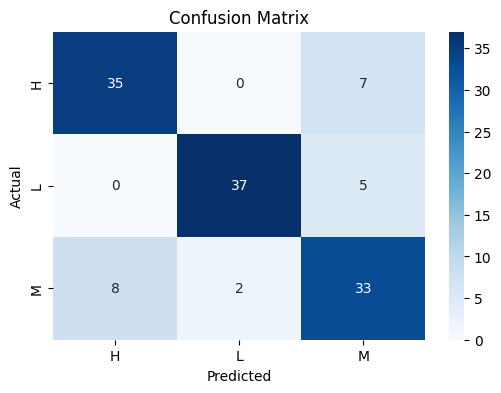

In [31]:
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=le.classes_)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [32]:
importances = model.feature_importances_
# Get feature names from OneHotEncoder transformers
ohe = preprocess.named_transformers_['cat']
ohe_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
remaining = [c for c in X.columns if c not in cat_cols]  # passthrough columns order
feature_names = ohe_feature_names + remaining


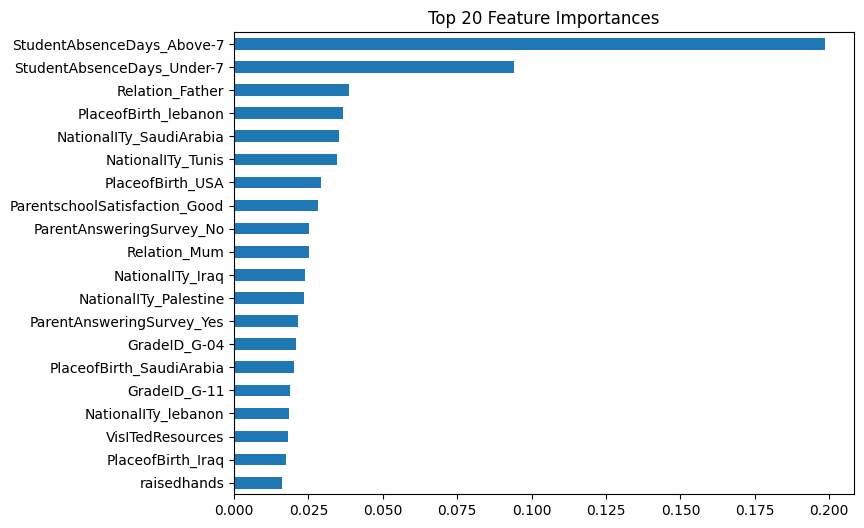

In [33]:
fi = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(20)
plt.figure(figsize=(8,6))
fi.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 20 Feature Importances')
plt.show()